<a href="https://colab.research.google.com/github/mhdhaikal22/data-science-2026/blob/main/Pertemuan9_%5BMUHAMMAD_HAIKAL%5D_%5B240401010269%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pertemuan 9 - Algoritma Klasifikasi (Bagian 1)

**Nama:** Muhammad Haikal  
**NIM:** 240401010269  
**Kelas:** IF401

In [1]:
# Load & EDA Singkat

from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0=malignant, 1=benign

print('Shape:', X.shape)
print('Distribusi target:')
print(pd.Series(y).value_counts(normalize=True).round(3))

Shape: (569, 30)
Distribusi target:
1    0.627
0    0.373
Name: proportion, dtype: float64


In [2]:
# Preprocessing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [3]:
# Latih Logistic Regression

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)

coef_df = pd.DataFrame({'Fitur': X.columns,
    'Koefisien': log_model.coef_[0]
    }).sort_values('Koefisien', key=abs, ascending=False)
print(coef_df.head())

                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616


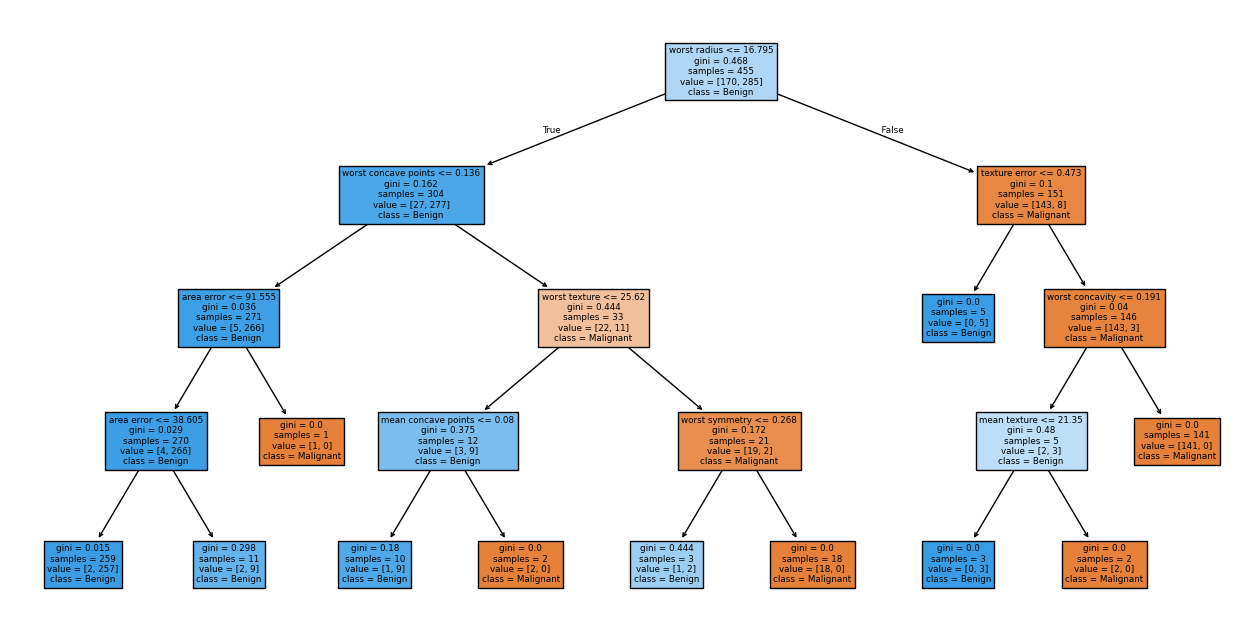

In [4]:
# Latih Decision Tree

from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

tree_model = DecisionTreeClassifier(max_depth=4,
    random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

plt.figure(figsize=(16, 8))
plot_tree(tree_model, feature_names=X.columns,
class_names=['Malignant','Benign'], filled=True)
plt.show()


==== Logistic Regression ====


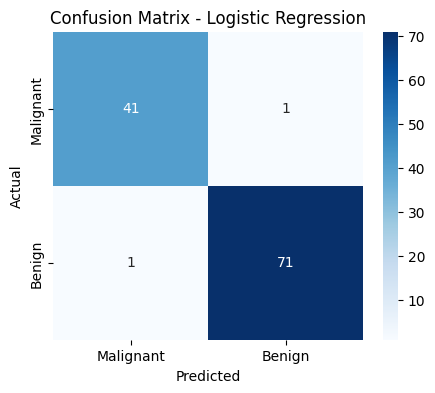

Accuracy : 0.982
Precision: 0.986
Recall   : 0.986
F1-Score : 0.986

==== Decision Tree ====


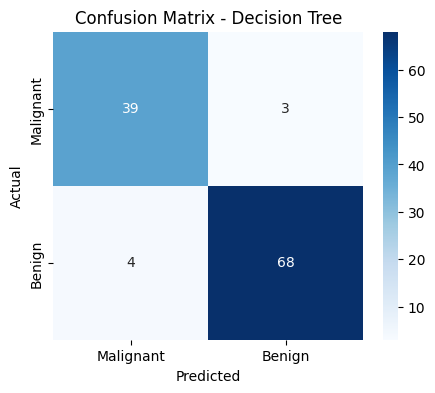

Accuracy : 0.939
Precision: 0.958
Recall   : 0.944
F1-Score : 0.951


In [5]:
# Evaluasi & Bandingkan

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns
import matplotlib.pyplot as plt

for name, y_pred in [
    ('Logistic Regression', y_pred_log),
    ('Decision Tree', y_pred_tree)
]:

    print(f"\n==== {name} ====")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Malignant', 'Benign'],
        yticklabels=['Malignant', 'Benign']
    )

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Metrik Evaluasi
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred):.3f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
    print(f"F1-Score : {f1_score(y_test, y_pred):.3f}")